### Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
# droping day, month, year
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
## Encoding
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [8]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

## separating independent and dependent features

In [11]:
x = df.drop('FWI', axis=1) # independent feature
y = df['FWI'] # dependent feature

In [12]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [13]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=41)

In [16]:
x_train.shape, x_test.shape

((182, 11), (61, 11))

In [17]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.632603,-0.276940,-0.330300,0.696636,0.485381,0.402618,0.612643,0.469295,0.544552,0.217014
RH,-0.632603,1.000000,0.284878,0.216989,-0.648727,-0.430816,-0.268378,-0.674245,-0.385272,-0.429688,-0.382272
Ws,-0.276940,0.284878,1.000000,0.187858,-0.202555,-0.023306,0.058029,-0.028594,0.009506,-0.128823,-0.205389
Rain,-0.330300,0.216989,0.187858,1.000000,-0.528326,-0.279693,-0.289968,-0.338240,-0.290936,-0.360923,-0.050380
FFMC,0.696636,-0.648727,-0.202555,-0.528326,1.000000,0.616007,0.522644,0.749150,0.607508,0.777949,0.213566
DMC,0.485381,-0.430816,-0.023306,-0.279693,0.616007,1.000000,0.878280,0.691288,0.982519,0.606479,0.194447
DC,0.402618,-0.268378,0.058029,-0.289968,0.522644,0.878280,1.000000,0.530794,0.941766,0.528517,-0.062961
ISI,0.612643,-0.674245,-0.028594,-0.338240,0.749150,0.691288,0.530794,1.000000,0.662441,0.751002,0.235096
BUI,0.469295,-0.385272,0.009506,-0.290936,0.607508,0.982519,0.941766,0.662441,1.000000,0.610694,0.096437
Classes,0.544552,-0.429688,-0.128823,-0.360923,0.777949,0.606479,0.528517,0.751002,0.610694,1.000000,0.132260


<Axes: >

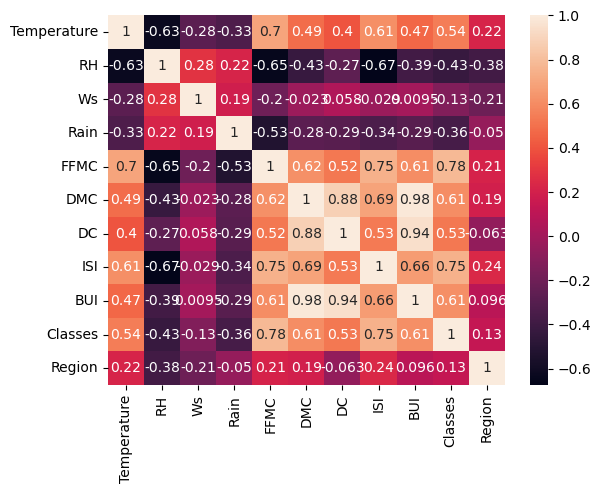

In [18]:
sns.heatmap(x_train.corr(), annot=True)

## selecting features based on correlation threshold value

In [19]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j])> threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
# asuming the threshold value as 0.85
corr_features = correlation(x_train, 0.85)

In [20]:
corr_features

{'BUI', 'DC'}

In [21]:
x_train.shape, x_test.shape

((182, 11), (61, 11))

In [22]:
## drop features when correlation is higher that 0.85
x_train.drop(corr_features, axis=1, inplace=True)
x_test.drop(corr_features, axis=1, inplace=True)
x_train.shape, x_test.shape

((182, 9), (61, 9))

### Feature Scaling  or Standardization

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [24]:
x_train_scaled

array([[-0.27688003,  0.85321886, -0.87860649, ..., -0.75597877,
        -1.08012345, -1.        ],
       [-0.27688003, -0.50298928, -1.57084191, ...,  0.16190308,
         0.9258201 , -1.        ],
       [-1.36644038, -0.29955806,  0.50586434, ...,  0.93857234,
         0.9258201 ,  1.        ],
       ...,
       [-0.00448995,  0.3107356 , -0.53248878, ..., -0.87365593,
        -1.08012345,  1.        ],
       [ 1.0850704 , -1.24890376, -0.87860649, ...,  0.84443061,
         0.9258201 ,  1.        ],
       [ 2.17463074, -2.13043906, -0.18637107, ...,  2.79787148,
         0.9258201 ,  1.        ]], shape=(182, 9))

## Box plot to understand the effect of Standardization

Text(0.5, 1.0, 'x_train After Scaling')

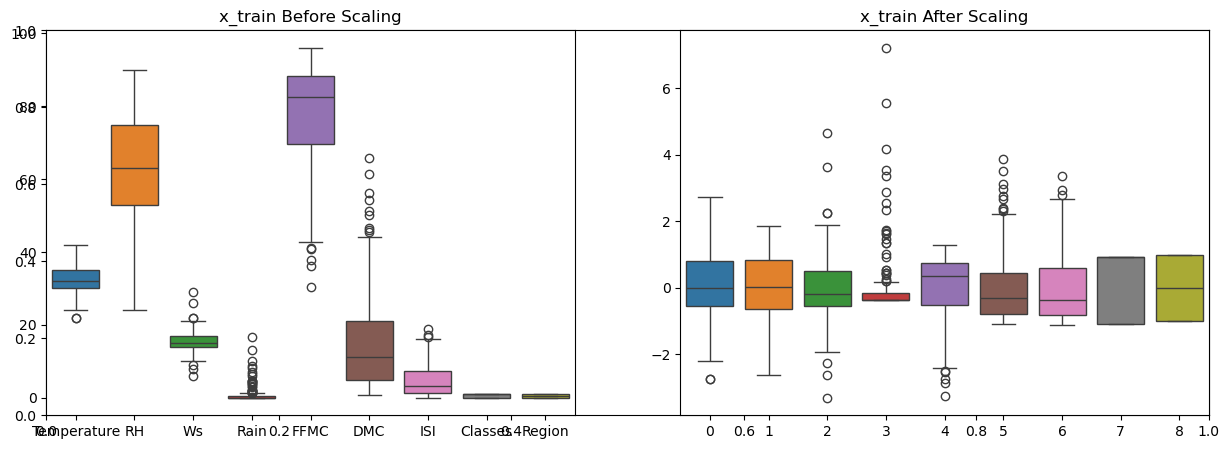

In [26]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('x_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train After Scaling')

## Linear Regression Model

Mean absolute error:  0.5670984536749405
R2 score:  0.9826446263791836


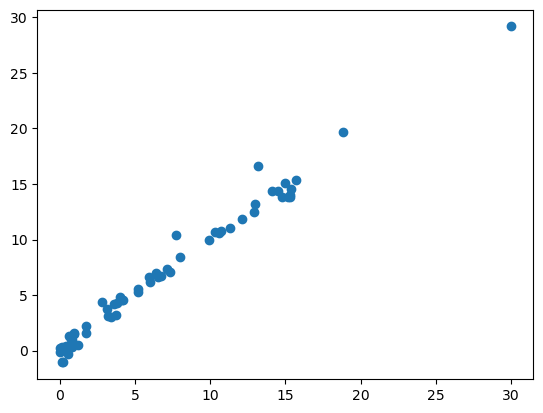

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
linreg = LinearRegression()
linreg.fit(x_train_scaled, y_train)
y_pred = linreg.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print('Mean absolute error: ',mae)
print('R2 score: ',score)
plt.scatter(y_test, y_pred)

## Lasso Regression

Mean absolute error 1.0185004953444192
R2 Score 0.9588635787062445


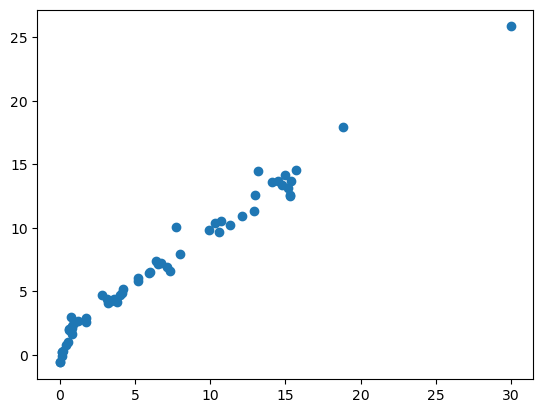

In [29]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
lasso = Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred = lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Cross Validation Lasso

In [30]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


Mean absolute error 0.5672525485685984
R2 Score 0.9823446955928771


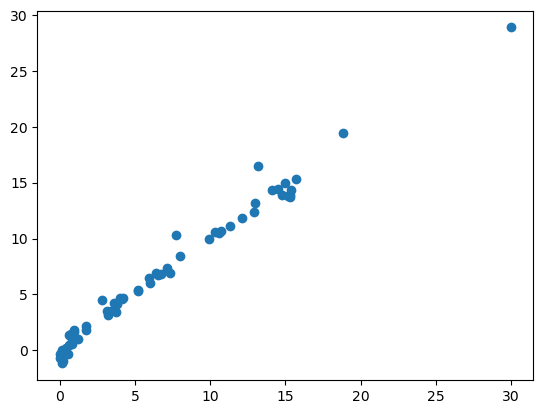

In [31]:
y_pred=lassocv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression model

Mean absolute error 0.5827892685716046
R2 Score 0.982027823305431


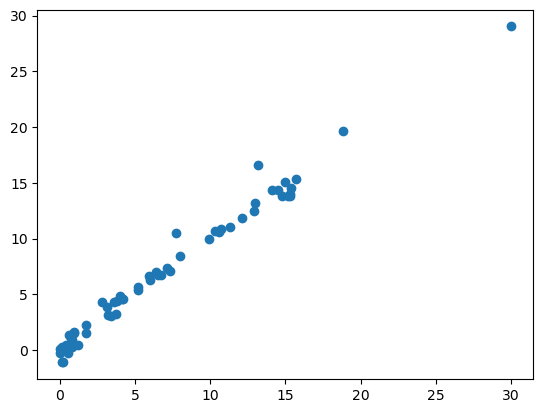

In [32]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Cross Validation Ridge

Mean absolute error 0.5827892685716046
R2 Score 0.982027823305431


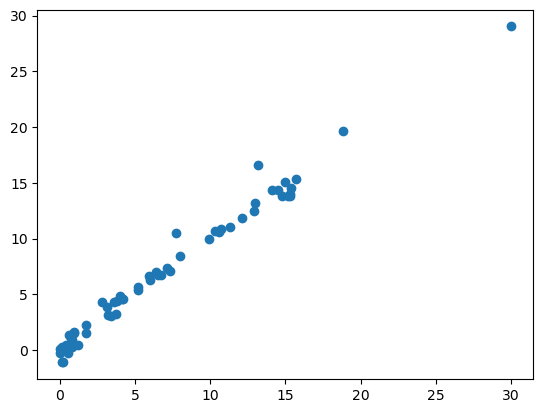

In [33]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Elasticnet Regression

Mean absolute error 1.6607844178200577
R2 Score 0.8913710465793633


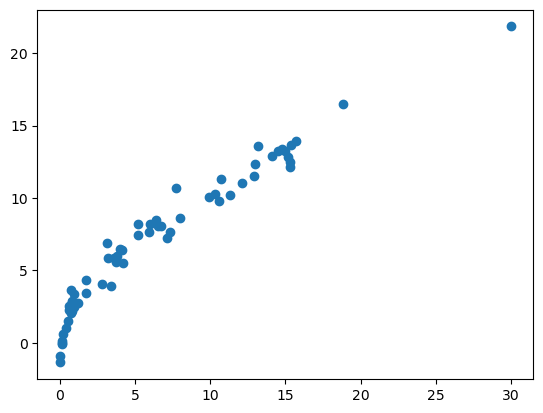

In [34]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Cross Validation Elasticnet 

Mean absolute error 0.6232227951872513
R2 Score 0.9804360060079451


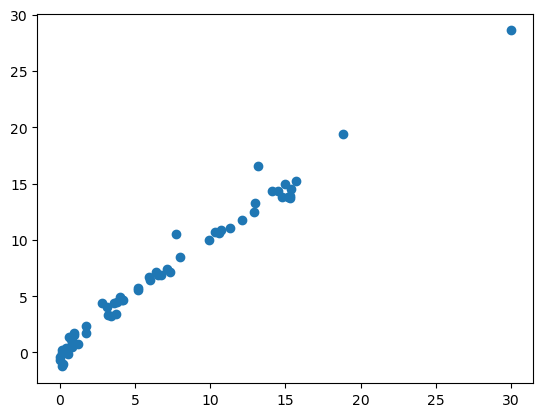

In [35]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Pickling

In [38]:
import pickle
pickle.dump(ridgecv, open('model.pkl', 'wb'))

In [37]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))